## Load Data

In [55]:
import pandas as pd

trn=pd.read_csv('./train_df.csv')
tst=pd.read_csv('./test_df.csv')
print(len(trn))
print(len(tst))
# trn.head(10)

36988
2991


# get rid of small contexts

In [56]:
trn.head()
# trn.iloc[1,[0,1]]  #the query is decent but the context does not answer it well

,query,context,embeddings,most_dissimilar_index,most_dissimilar_context,most_dissimilar_query
0,What safeguards are in place to protect the in...,Information We Collect From Other Sources We m...,[ 2.25806590e-02 1.24354791e-02 -4.27756980e-...,0,If such Standard Cost methodology change resul...,What triggers the reversion to the former Stan...
1,Are there provisions for payment advances?,4. PAYMENT,[ 5.34060374e-02 6.63839728e-02 -2.03104578e-...,13507,A. Section 5.9 of the Commercial License is am...,What obligations does Bioamber have regarding ...
2,Is there a guarantee from the manufacturers re...,Each of the Suppliers warrants that the Produc...,[-1.00221671e-01 -1.73612703e-02 5.37407212e-...,18120,We do not obtain your age range and gender.,What demographic data is excluded?
3,What type of authorization has the video confe...,Skype hereby grants to Online BVI and the Comp...,[-5.64502142e-02 -5.12508973e-02 2.16972455e-...,7830,"In order to keep your exclusivity, you agree t...",What are the annual purchase minimums for main...
4,Can the Blockchain Administrator arrange for t...,(a) The Fund hereby employs the Blockchain Adm...,[ 2.67564338e-02 5.32581210e-02 -7.69327506e-...,2600,8. Insurance. During the Term of this Agreemen...,What is the minimum amount of Commercial Gener...


In [57]:
#it looks like the data is chunked poorly
def dumptitlecontexts(df, cols=['context','most_dissimilar_context']):
    nr=len(df)
    #drop all two word rows
    for col in cols:
        df = df[~df[col].str.split().apply(lambda x: len(x) <= 2)]

    #drop all all caps rows (presumably titles)
    for col in cols:
        df = df[~df[col].str.isupper()]

    #reset index
    df.reset_index(drop=True, inplace=True)

    print(f'dropped {nr -len(df)} rows')
    return df

trn=dumptitlecontexts(trn, cols=['context'])
tst=dumptitlecontexts(tst, cols=['context'])

dropped 1716 rows
dropped 350 rows


In [58]:
# cols=[0,1]
# row=36982
# for col in cols:
#     print(trn.loc[row][col])

# lst=[]
# for _,row in trn.iterrows():
#     # print(row.iloc[1])
#     if "safeguard" in row[1]:
#         lst.append(row[1])
# lst
# # print(len(lst))
# trn.columns

# How are most_dissimilar_index (and contexts distributed?)

In [59]:
trn.context.nunique()

3348

In [60]:
#how many unique values in most_dissimilar_index
print(f'unique most_dissimilar_index={len(trn.most_dissimilar_index.value_counts())}')
print(f'unique most_dissimilar_context={len(trn.most_dissimilar_context.value_counts())}')
print(f'unique context={len(trn.context.value_counts())}')

unique most_dissimilar_index=586
unique most_dissimilar_context=530
unique context=3348


In [61]:
# trn.most_dissimilar_index.value_counts().sort_values(ascending=False)

#get the index of the top n most frequently occurring index
# inds=trn.most_dissimilar_index.value_counts().sort_values(ascending=False).index.tolist()[:20]
# cols=['query','context']
# trn.loc[inds,cols]


<Axes: ylabel='most_dissimilar_index'>

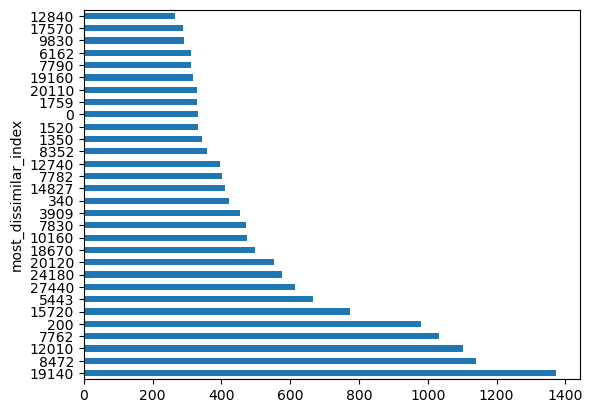

In [62]:
#how many times is a particular index reused in the training set
# for i, v in trn.most_dissimilar_index.value_counts().items():
#     print(i,v)

trn.most_dissimilar_index.value_counts().sort_values(ascending=False).head(30).plot(kind='barh')


In [63]:
## just a few examples of the most frequently occurring most_dissimilar_index
for i in [19140, 8472,12010,7762,200]:
    print(trn.iloc[i,1])

This Agreement shall be governed by and construed in accordance with the internal laws of the State of California applicable to agreements made and to be performed entirely within such state, without regard to the conflicts of law principles of such state; provided that any matters relating to the construction or effect of any Patent will be governed by the patent laws of the relevant jurisdiction in which such Patent is granted.
Article 4. Development and Regulatory Activities
PHASE  I:     NOVEMBER  8TH The  existing site located at Spinrecords.com/Nettaxi shall be launched - target date  one week from agreement date. This site shall contain the web based e-mail from  Nettaxi.  This  site shall also use Spinstore and Spinware as it currently exists  on  the  site.

Nettaxi  will begin development of the music template for the home page builder. Spinrecords  will  submit their existing list of members to Nettaxi to integrate the  homepage  builder  database  and  resolve  duplicate  I

# Get rid of additional columns, we will rebuild hard negatives another way



In [64]:
len(tst)

2641

In [65]:
# l=[i for i in list(range(100))]


# b=l[(len(l)-40):(len(l)-20)]
# c=l[len(l)-20:]
# a=l[:(len(l)-40)]
# print(a)
# print(b)
# print(c)

In [66]:
# trn.drop(columns=cols_trn_drop, inplace=True)
# tst.drop(columns=cols_tst_drop, inplace=True)

# trn.rename(columns={'query': 'anchor', 'context':'positive'}, inplace=True)
# tst.rename(columns={'query': 'anchor', 'context':'positive'}, inplace=True)

# trn['id']=range(len(trn))
# tst['id']=range(len(tst))
# 


In [67]:
# concatenate train and test
# df=pd.concat([trn,tst], axis=0)

# ##get rid of all context duplicates, otherwise MNR loss will likely get a duplicate positive as a negative

# df=df.drop_duplicates(subset=['context'])
# print(len(df))
# df['id']=range(len(df))

In [68]:
##get rid of all context duplicates, otherwise MNR loss will likely get a duplicate positive as a negative
#lets try filtering on unique positives
def dump_dups(df,col):
    nr=len(df)
    df=df.drop_duplicates(subset=[col])
    df.reset_index(drop=True, inplace=True)
    print(f'dropped {nr -len(df)} rows. have {len(df)} rows left')
    return df
trn=dump_dups(trn,'context')
# tst=dump_dups(tst,'context')


dropped 31924 rows. have 3348 rows left


In [69]:
def renamecols(df):
    df.rename(columns={'query': 'anchor', 'context':'positive'}, inplace=True)
    cols_to_drop=[c for c in df.columns if c not in ['anchor','positive']]
    df.drop(columns=cols_to_drop, inplace=True)
    return df
trn=renamecols(trn)
tst=renamecols(tst)

trn['id']=range(len(trn))
tst['id']=range(len(tst))

In [70]:
trn.head()

,anchor,positive,id
0,What safeguards are in place to protect the in...,Information We Collect From Other Sources We m...,0
1,Is there a guarantee from the manufacturers re...,Each of the Suppliers warrants that the Produc...,1
2,What type of authorization has the video confe...,Skype hereby grants to Online BVI and the Comp...,2
3,Can the Blockchain Administrator arrange for t...,(a) The Fund hereby employs the Blockchain Adm...,3
4,What happens if a Party fails to retain record...,Each Party will retain such records for at lea...,4


In [71]:
print(trn.positive.nunique()==len(trn))
print(f'len train={len(trn)}')
print(f'len test={len(tst)}')

True
len train=3348
len test=2641


In [72]:
#split out eval set from train
evalsize=400
eval=trn[len(trn)-evalsize:]

# trn=trn[:10000]

trn.to_json("trn.json", orient="records")
eval.to_json("eval.json", orient="records")
tst.to_json("tst.json", orient="records")

from datasets import load_dataset
train_dataset = load_dataset("json", data_files="trn.json", split="train")
eval_dataset = load_dataset("json", data_files="eval.json", split="train")
tst_dataset = load_dataset("json", data_files="tst.json", split="train")

Generating train split: 3348 examples [00:00, 135205.03 examples/s]


Generating train split: 400 examples [00:00, 175659.26 examples/s]
Generating train split: 2641 examples [00:00, 126697.44 examples/s]


In [73]:
eval_dataset[:2]


{'positive': ['1.1.  Affiliate shall mean, when used with reference to a Party, any individual or entity directly or indirectly controlling, controlled by or under common control with such Party.  For purposes of this definition, "control" means the direct or indirect ownership of at least 50% of the outstanding voting power of a Party, or the right to control the policy decisions of such Party.',
  "2.1 Products License Grant. Subject to the terms and conditions of this Agreement, Google grants to Distributor a [* ] license during the  Term to: (a) bundle the Distribution Products, in machine-readable binary code format only, solely with Distributor App(s); (b) distribute  Bundles directly (or indirectly, subject to Clause 2.2 (Third Party Distribution)) to End Users in the Territory; (c) when indicated by the  applicable Criteria Checker and requested by the End User in accordance with clause 3.2 (Form of Distribution Offering), install the  Chrome Browser or the Google Toolbar (as a

In [35]:
tst_dataset[:2]

{'most_dissimilar_context': ['1.2     "SpinRecords.com  Pages"  means the SpinRecords.com Web-based pages that incorporate certain SpinRecords.com services, as the same may be updated or modified  from  time  to  time  in  SpinRecords.com\'s sole discretion, currently located  at  http://www.spinrecords.com.',
  "If you disable cookies off, some features will be disabled It won't affect the users experience that make your site experience more efficient and some of our services will not function properly."],
 'anchor': ['Does this agreement protect XACCT from claims for special damages?',
  'What commitment does AMAG make with each Forecast?'],
 'positive': ['7.2      Consequential Damages. UNDER NO CIRCUMSTANCES, INCLUDING NEGLIGENCE,          SHALL XACCT BE LIABLE FOR ANY SPECIAL, INCIDENTAL OR CONSEQUENTIAL          DAMAGES INCLUDING, WITHOUT LIMITATION, DAMAGES FOR LOST PROFITS, LOSS          OF DATA, OR COSTS OF PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES,          ARISING IN ANY W